# Customer Churn Prediction - Multi-Algorithm Classification Showdown

**Practical Exam - Supervised Learning (Set B)**

This notebook builds and compares four supervised learning classification models
(KNN, Naive Bayes, SVM, Decision Tree) to predict customer churn using the
IBM Telco Customer Churn dataset. The goal is to help a telecom retention team
identify customers who are likely to churn so that the business can act early
and reduce revenue loss.

## Step 1: Problem Framing and Theory Notes

### 1. What is Customer Churn? Why is predicting churn valuable for a business like Jio or Airtel?

Customer churn means a customer stops using a company's service and moves to a
competitor or simply cancels the subscription. For telecom companies such as
Jio or Airtel, predicting churn is valuable because it directly protects
revenue.

- **CAC (Customer Acquisition Cost)** is the money spent on marketing and
  offers to acquire one new customer. This cost is usually high.
- **CLV (Customer Lifetime Value)** is the total revenue a company expects to
  earn from a customer over the entire relationship.
- Acquiring a new customer to replace a lost one costs far more than
  retaining an existing one (CAC is usually much higher than the cost of a
  retention offer). If a company can predict churn in advance, it can offer
  discounts or better plans to the customer before they leave, protecting the
  CLV instead of spending CAC again on a new customer.

### 2. Confusion Matrix - TP, TN, FP, FN and Business Cost in Churn Context

- **True Positive (TP):** Model predicts churn, customer actually churns.
- **True Negative (TN):** Model predicts no churn, customer actually stays.
- **False Positive (FP):** Model predicts churn, but customer actually stays.
- **False Negative (FN):** Model predicts no churn, but customer actually churns.

**Business cost of a False Negative:** This is the most expensive mistake.
The retention team believes the customer is safe, so no offer is made, and
the company silently loses that customer along with all their future
revenue (CLV).

**Business cost of a False Positive:** This is cheaper. The company wastes a
retention offer (discount, call, coupon) on a customer who was never going
to leave. It costs some money, but the customer is not lost.

### 3. What is Class Imbalance? Does the Telco Churn dataset have it? How does SMOTE address it?

Class imbalance happens when one class in the target variable has far more
samples than the other class. In this dataset, the "No churn" class has many
more customers than the "Yes churn" class, so it is imbalanced (churn is
roughly a quarter of all customers, verified in Step 2).

**SMOTE (Synthetic Minority Oversampling Technique)** addresses this by
creating new synthetic samples of the minority class (churners). Instead of
simply duplicating existing rows, it picks a minority class point, finds its
nearest minority-class neighbours, and generates new points along the line
segments joining them. This gives the model a more balanced training set
without throwing away any majority class information.

### 4. How each of the 4 algorithms works

- **KNN (K-Nearest Neighbours):** Stores the entire training data. To
  classify a new customer, it finds the "k" closest training points (by
  distance) and takes a majority vote of their labels. It is a distance-based,
  lazy learner with no real training phase.
- **Naive Bayes:** Uses Bayes' theorem to calculate the probability of each
  class given the feature values, assuming all features are independent of
  each other. It picks the class with the highest posterior probability. It
  is fast and works well even with limited data.
- **SVM (Support Vector Machine):** Finds the hyperplane that best separates
  the two classes with the maximum margin. With the RBF kernel, it can map
  data into a higher dimensional space to find non-linear decision
  boundaries.
- **Decision Tree:** Splits the data repeatedly on the feature and threshold
  that best separates the classes (using a criterion like Gini impurity),
  building a tree of if-else rules until a stopping condition is reached. It
  is easy to interpret because each path from root to leaf is a rule.

### 5. When would you choose Precision over Recall as your primary metric?

Precision would be the primary metric when the cost of a False Positive is
high, i.e., when acting on a wrong churn prediction is expensive. For
example, if the retention offer is very costly (a free year of service or a
large discount), the business cannot afford to give it to customers who were
never going to leave, so precision becomes more important. In most churn
situations Recall is prioritized instead, because missing a real churner
(False Negative) usually costs more than making an unnecessary retention
call.

## Importing Libraries

We import all the libraries needed for data handling, visualization, preprocessing, modeling, and evaluation.

In [503]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import warnings
warnings.filterwarnings("ignore")

## Step 2: Dataset Loading and Exploratory Data Analysis

### 2.1 Load and Inspect

In [506]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [507]:
df.shape

(7043, 21)

In [508]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [509]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [510]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [511]:
# Check rows where TotalCharges cannot be converted to a number
non_numeric_mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print("Number of problematic rows:", non_numeric_mask.sum())
df.loc[non_numeric_mask, ["customerID", "tenure", "TotalCharges"]]

Number of problematic rows: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


**Conclusion:** The `TotalCharges` column contains blank/whitespace strings for a small number of customers, all of whom have `tenure` equal to 0 (brand new customers with no billing history yet). This is why pandas reads the column as text (object) instead of a numeric type. We convert the column to float64 and will handle these missing values in the preprocessing step by filling them with the median.

In [513]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges dtype after conversion:", df["TotalCharges"].dtype)
print("Missing values in TotalCharges:", df["TotalCharges"].isna().sum())

TotalCharges dtype after conversion: float64
Missing values in TotalCharges: 11


Now let us check the class balance of the target variable `Churn`.

In [515]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100
print("Churn counts:\n", churn_counts)
print("\nChurn percentage:\n", churn_percent.round(2))

Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Conclusion:** About 26.5% of customers have churned while about 73.5% have stayed with the company. This is a moderately imbalanced binary classification problem.

### 2.2 Univariate Analysis

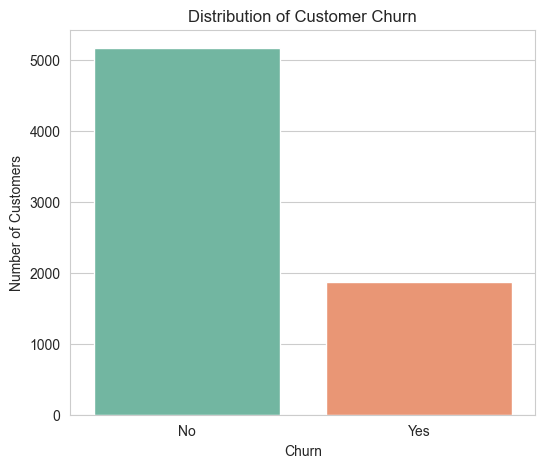

In [518]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("churn_countplot.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** The chart confirms the class imbalance seen earlier - far more customers stayed (No) than churned (Yes). Roughly 1 in 4 customers left the service. From a business point of view, even this "minority" group represents a large amount of lost recurring revenue every month, which is why identifying them early matters. This pattern confirms that our target variable needs imbalance handling before modeling.

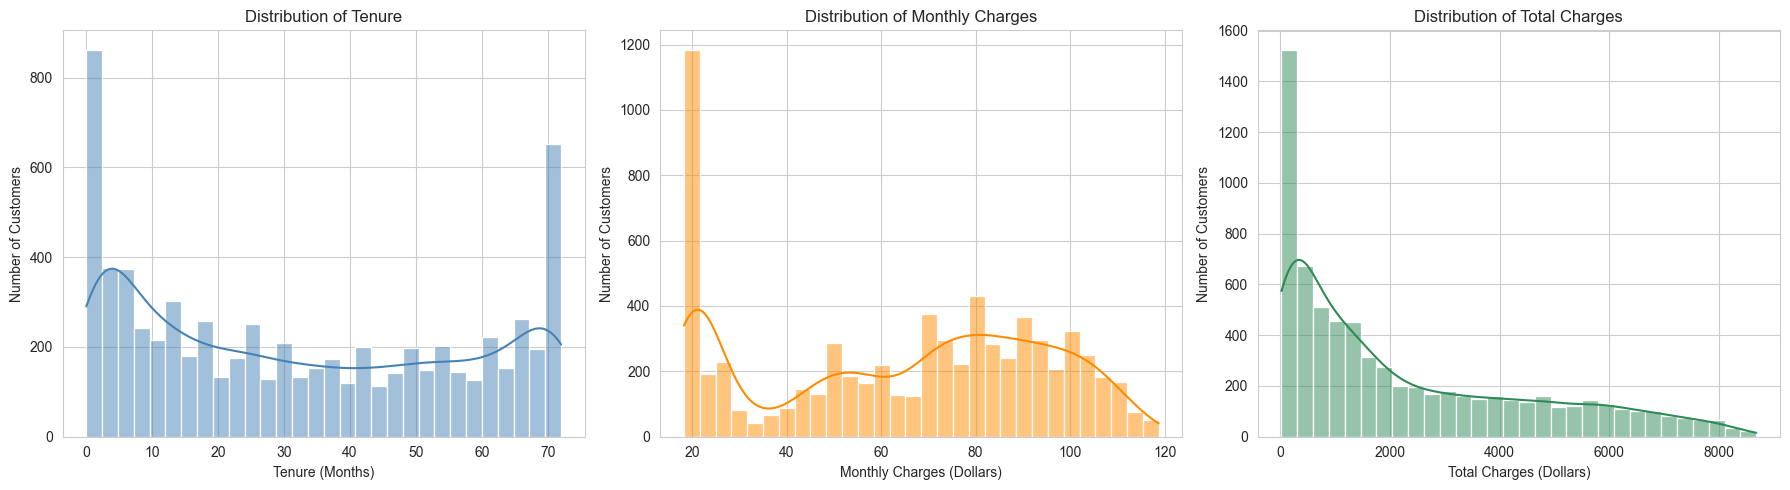

In [520]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["tenure"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Tenure")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Number of Customers")

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Monthly Charges")
axes[1].set_xlabel("Monthly Charges (Dollars)")
axes[1].set_ylabel("Number of Customers")

sns.histplot(df["TotalCharges"].dropna(), bins=30, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Distribution of Total Charges")
axes[2].set_xlabel("Total Charges (Dollars)")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("numeric_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** Tenure shows two peaks - many customers are either very new under a few months or long-term near 72 months, with fewer customers in the middle. MonthlyCharges is spread across a wide range with a rise around 20 basic plans and another cluster around 70-100 bundled plans. TotalCharges is heavily right-skewed since it naturally grows with tenure. This tells us that new customers and billing amount will likely be important churn signals.

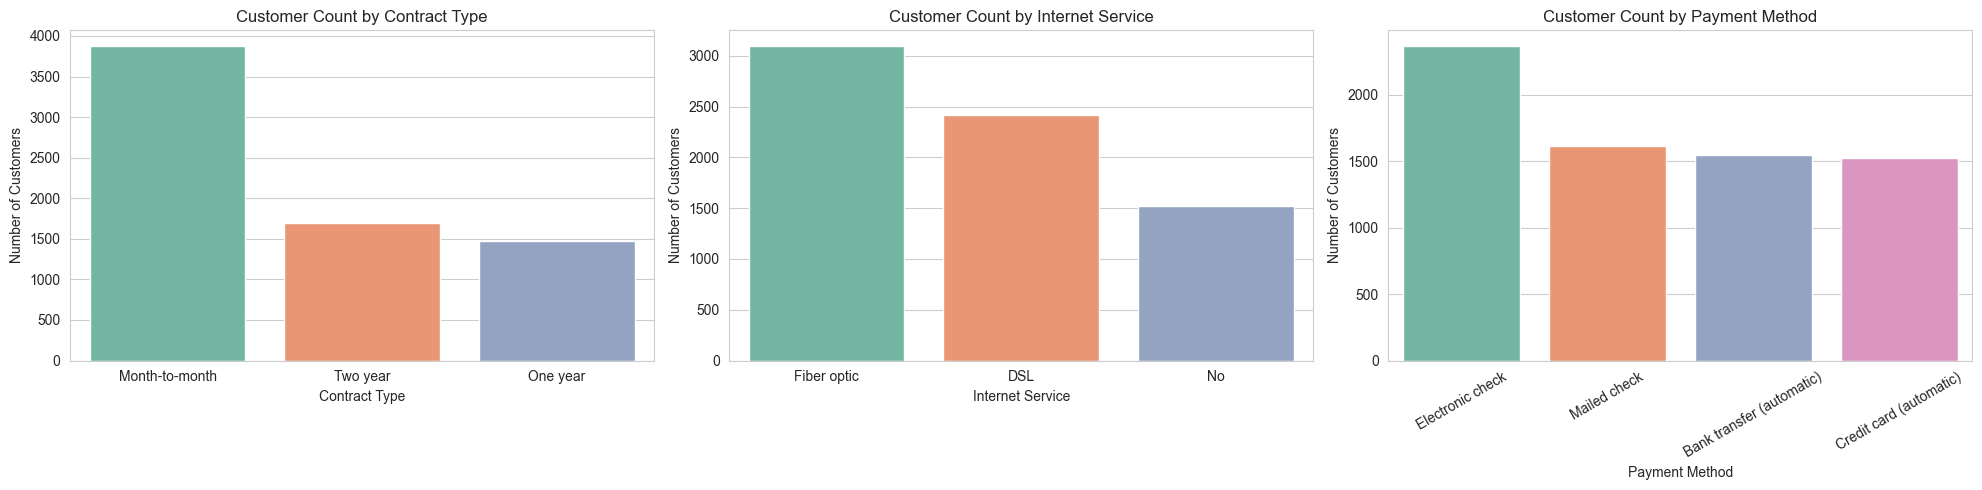

In [522]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(data=df, x="Contract", ax=axes[0], palette="Set2",
              order=df["Contract"].value_counts().index)
axes[0].set_title("Customer Count by Contract Type")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Number of Customers")

sns.countplot(data=df, x="InternetService", ax=axes[1], palette="Set2",
              order=df["InternetService"].value_counts().index)
axes[1].set_title("Customer Count by Internet Service")
axes[1].set_xlabel("Internet Service")
axes[1].set_ylabel("Number of Customers")

sns.countplot(data=df, x="PaymentMethod", ax=axes[2], palette="Set2",
              order=df["PaymentMethod"].value_counts().index)
axes[2].set_title("Customer Count by Payment Method")
axes[2].set_xlabel("Payment Method")
axes[2].set_ylabel("Number of Customers")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("categorical_countplots.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** Most customers are on Month-to-month contracts, followed by Two year and One year contracts. Fibre optic is the most common internet service, followed by DSL, with some customers having no internet service at all. Electronic check is the most used payment method. Since month-to-month customers have no long-term commitment, we expect them to show a higher churn rate.

### 2.3 Bivariate Analysis

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


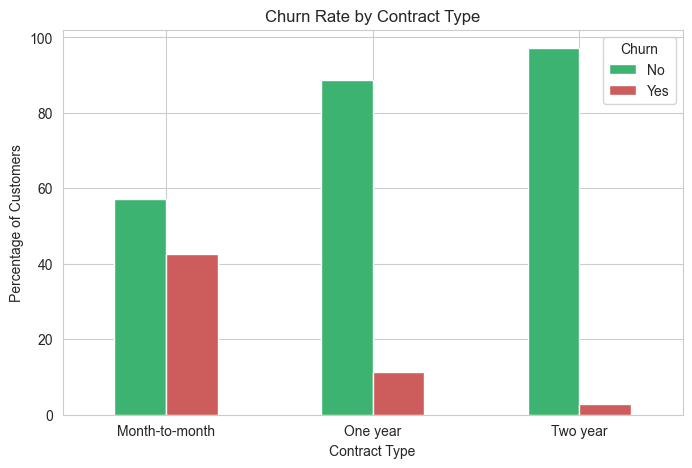

In [525]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn = contract_churn.sort_values(by="Yes", ascending=False)
print(contract_churn.round(2))

contract_churn.plot(kind="bar", figsize=(8, 5), color=["mediumseagreen", "indianred"])
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.savefig("churn_rate_by_contract.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** Month-to-month contract customers churn at a much higher rate than One year or Two year contract customers. This is the single strongest churn signal in the dataset - customers without a long-term commitment can leave anytime, and many do.

Churn                 No    Yes
tenure_bucket_eda              
0-12               52.56  47.44
13-24              71.29  28.71
25-48              79.61  20.39
49-72              90.49   9.51


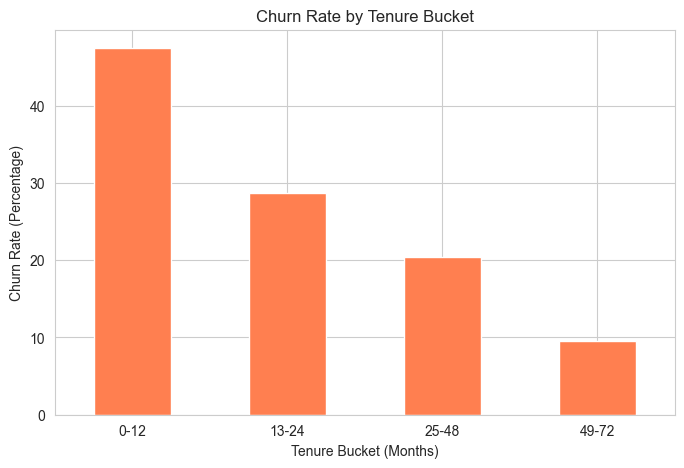

In [527]:
bins = [0, 12, 24, 48, 72]
labels = ["0-12", "13-24", "25-48", "49-72"]
df["tenure_bucket_eda"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

tenure_churn = pd.crosstab(df["tenure_bucket_eda"], df["Churn"], normalize="index") * 100
print(tenure_churn.round(2))

tenure_churn["Yes"].plot(kind="bar", figsize=(8, 5), color="coral")
plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket (Months)")
plt.ylabel("Churn Rate (Percentage)")
plt.xticks(rotation=0)
plt.savefig("churn_rate_by_tenure_bucket.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** Churn rate is highest for customers in their first 12 months and decreases steadily as tenure increases. Customers who stay past 4 years (49-72 months) churn the least. This shows that the first year is the most critical window for retention - the business should focus onboarding and engagement efforts on new customers to build loyalty early.

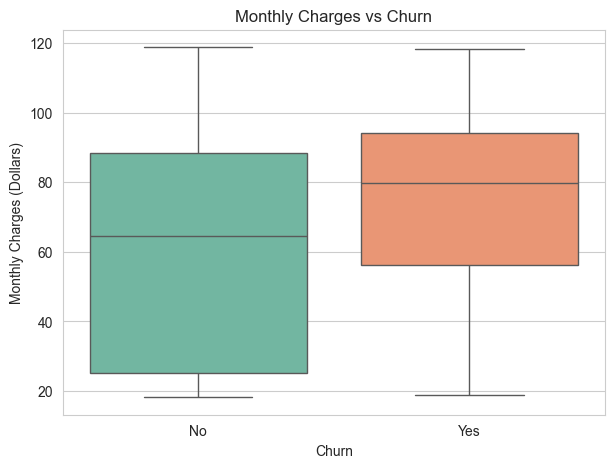

In [529]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Set2")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges (Dollars)")
plt.savefig("monthlycharges_vs_churn_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** Customers who churned tend to have higher median monthly charges than customers who stayed. This suggests that price sensitivity is a factor in churn - customers paying more per month (often for fibre optic and add-on services) are more likely to leave, possibly due to cost or dissatisfaction with the value received for that price.

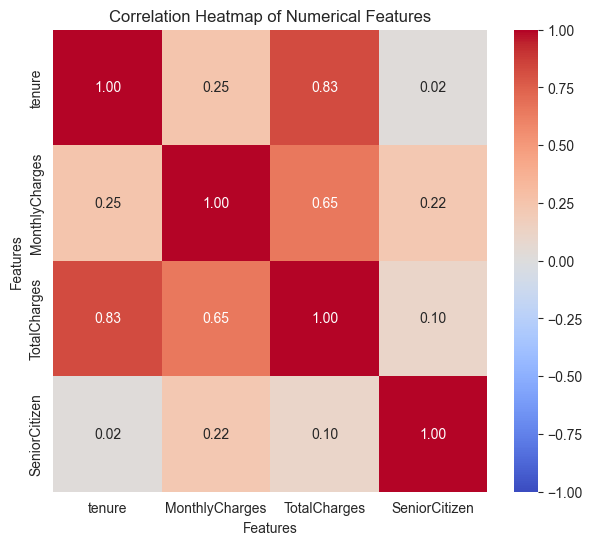

In [531]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** `TotalCharges` is very strongly correlated with `tenure` , and moderately correlated with `MonthlyCharges`. `SeniorCitizen` shows weak correlation with the other numeric features. This strong correlation between tenure and TotalCharges is useful to keep in mind, since highly correlated features can sometimes add redundant information to distance-based models like KNN and SVM.

**Key insight check:** Our EDA confirms the expected high-risk churn segment - Month-to-month contract customers with high MonthlyCharges and low tenure show the highest churn rates. All three individual analyses (contract type, tenure bucket, and monthly charges) point consistently to this same group, which will be an important pattern for the retention team to target.

## Step 3: Data Preprocessing and Feature Engineering

### 3.1 Drop and Clean

In [536]:
df_clean = df.drop(columns=["customerID", "tenure_bucket_eda"])

median_total_charges = df_clean["TotalCharges"].median()
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(median_total_charges)

print("Missing values remaining in TotalCharges:", df_clean["TotalCharges"].isna().sum())
print("Median used to fill missing values:", median_total_charges)
df_clean.shape

Missing values remaining in TotalCharges: 0
Median used to fill missing values: 1397.475


(7043, 20)

**Conclusion:** The `customerID` column has been removed and the missing `TotalCharges` values have been filled using the median, which is a robust choice since the distribution is right-skewed and the median is less affected by outliers than the mean.

### 3.2 Feature Engineering

In [539]:
def assign_tenure_group(tenure):
    if tenure <= 12:
        return "New"
    elif tenure <= 36:
        return "Mid"
    elif tenure <= 60:
        return "Senior"
    else:
        return "Loyal"

df_clean["tenure_group"] = df_clean["tenure"].apply(assign_tenure_group)

service_columns = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df_clean["num_services"] = df_clean[service_columns].apply(
    lambda row: sum(row == "Yes"), axis=1)

df_clean["AutoPay"] = df_clean["PaymentMethod"].apply(
    lambda x: 1 if "automatic" in x.lower() else 0)

df_clean[["tenure", "tenure_group", "num_services", "AutoPay"]].head(10)

,tenure,tenure_group,num_services,AutoPay
0,1,New,1,0
1,34,Mid,2,0
2,2,New,2,0
3,45,Senior,3,1
4,2,New,0,0
5,8,New,3,0
6,22,Mid,2,1
7,10,New,1,0
8,28,Mid,4,0
9,62,Loyal,2,1


### 3.3 Encoding

In [541]:
binary_columns = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_columns:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0})

df_clean["gender"] = df_clean["gender"].map({"Male": 1, "Female": 0})
df_clean[binary_columns + ["gender"]].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn,gender
0,1,0,0,1,0,0
1,0,0,1,0,0,1
2,0,0,1,1,1,1
3,0,0,0,0,0,1
4,0,0,1,1,1,0


In [542]:
onehot_columns = ["InternetService", "Contract", "PaymentMethod"]
df_clean = pd.get_dummies(df_clean, columns=onehot_columns, drop_first=False)

columns_to_drop = service_columns + ["MultipleLines"]
df_clean = df_clean.drop(columns=columns_to_drop)

tenure_order = {"New": 0, "Mid": 1, "Senior": 2, "Loyal": 3}
df_clean["tenure_group"] = df_clean["tenure_group"].map(tenure_order)

bool_cols = df_clean.select_dtypes(include="bool").columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print("Shape after encoding:", df_clean.shape)
df_clean.head()

Shape after encoding: (7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,1,0,1,0,0,0,0,1,0


**Conclusion:** All categorical columns have been converted to numeric form. 

### 3.4 Scaling

In [545]:
scale_columns = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]
scaler = StandardScaler()
df_clean[scale_columns] = scaler.fit_transform(df_clean[scale_columns])

df_clean[scale_columns].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,num_services
count,7043.00,7043.00,7043.00,7043.00
mean,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.32,-1.55,-1.00,-1.10
25%,-0.95,-0.97,-0.83,-1.10
50%,-0.14,0.19,-0.39,-0.02
75%,0.92,0.83,0.66,0.52
max,1.61,1.79,2.83,2.14


**Conclusion:** The four numerical columns have been standardized to have a mean of 0 and a standard deviation of 1. 

### 3.5 Handle Class Imbalance

In [548]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

print("Overall class distribution before split:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Overall class distribution before split:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


### 3.6 Train-Test Split

In [550]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

In [551]:
print("Class counts in training set BEFORE SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass counts in training set AFTER SMOTE:")
print(y_train_sm.value_counts())

Class counts in training set BEFORE SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

Class counts in training set AFTER SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


**Conclusion:** Before SMOTE, the training set mirrors the original imbalance (roughly 73% No, 27% Yes). After applying SMOTE, both classes are perfectly balanced in the training set. Crucially, SMOTE was fit only on `X_train`/`y_train` - the test set (`X_test`, `y_test`) remains untouched and imbalanced, exactly as real, unseen customer data would be.

## Step 4: Model Building - KNN and Naive Bayes

In [554]:
results = {}  # will store metrics for every final tuned model, used in Step 6

def evaluate_model(name, model, X_te, y_te, y_pred, y_proba):
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, pos_label=1)
    rec = recall_score(y_te, y_pred, pos_label=1)
    f1 = f1_score(y_te, y_pred, pos_label=1)
    auc = roc_auc_score(y_te, y_proba)

    print(f"----- {name} -----")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (Churn class): {prec:.4f}")
    print(f"Recall    (Churn class): {rec:.4f}")
    print(f"F1-Score  (Churn class): {f1:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_te, y_pred))

    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}


def plot_confusion_matrix(name, y_te, y_pred):
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    filename = name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_roc(name, y_te, y_proba):
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color="darkorange")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    filename = name.lower().replace(" ", "_") + "_roc_curve.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

### 4.1 K-Nearest Neighbours (KNN)

In [556]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_sm, y_train_sm)

y_pred_knn_base = knn_baseline.predict(X_test)
y_proba_knn_base = knn_baseline.predict_proba(X_test)[:, 1]

_ = evaluate_model("KNN Baseline (k=5)", knn_baseline, X_test, y_test,
                    y_pred_knn_base, y_proba_knn_base)

----- KNN Baseline (k=5) -----
Accuracy : 0.7353
Precision (Churn class): 0.5010
Recall    (Churn class): 0.6872
F1-Score  (Churn class): 0.5795
AUC-ROC  : 0.7874

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.75      0.81      1035
           1       0.50      0.69      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.69      1409
weighted avg       0.77      0.74      0.75      1409



**Conclusion:** The baseline KNN model with k=5 gives us a reference point. Next we tune the value of k to see if a different neighbourhood size improves the F1-score for the Churn class.

In [558]:
k_values = [1, 3, 5, 7, 9, 11, 15]
k_f1_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_sm, y_train_sm, cv=5, scoring="f1")
    k_f1_scores.append(scores.mean())
    print(f"k = {k:2d} -> Mean CV F1-Score = {scores.mean():.4f}")

best_k = k_values[int(np.argmax(k_f1_scores))]
print("\nBest k based on cross-validated F1-Score:", best_k)

k =  1 -> Mean CV F1-Score = 0.8201
k =  3 -> Mean CV F1-Score = 0.8206
k =  5 -> Mean CV F1-Score = 0.8128
k =  7 -> Mean CV F1-Score = 0.8104
k =  9 -> Mean CV F1-Score = 0.8067
k = 11 -> Mean CV F1-Score = 0.8010
k = 15 -> Mean CV F1-Score = 0.7979

Best k based on cross-validated F1-Score: 3


k =  9 -> Mean CV F1-Score = 0.8067


k = 11 -> Mean CV F1-Score = 0.8009


k = 15 -> Mean CV F1-Score = 0.7979

Best k based on cross-validated F1-Score: 3


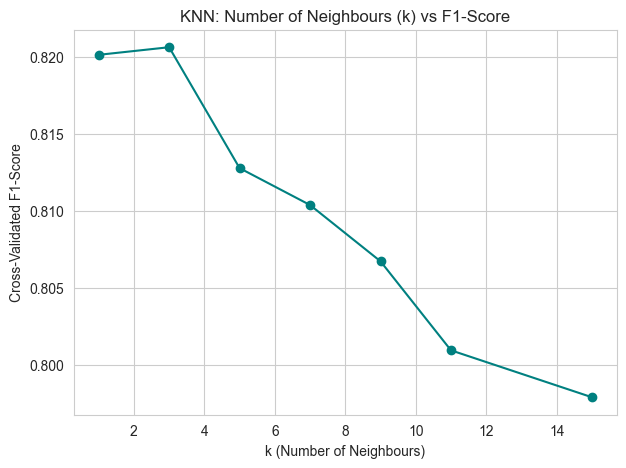

In [559]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, k_f1_scores, marker="o", color="teal")
plt.title("KNN: Number of Neighbours (k) vs F1-Score")
plt.xlabel("k (Number of Neighbours)")
plt.ylabel("Cross-Validated F1-Score")
plt.savefig("knn_k_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** The plot shows how the F1-score changes as k increases. Very small k values can overfit to noise, while very large k values can oversmooth the decision boundary and miss real churners. The best k identified above balances both effects and is used to retrain the final KNN model below.

In [561]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_sm, y_train_sm)

y_pred_knn = knn_final.predict(X_test)
y_proba_knn = knn_final.predict_proba(X_test)[:, 1]

start_time = time.time()
knn_final.fit(X_train_sm, y_train_sm)
knn_train_time = time.time() - start_time

knn_metrics = evaluate_model(f"KNN (k={best_k})", knn_final, X_test, y_test,
                              y_pred_knn, y_proba_knn)
knn_metrics["Training Time"] = knn_train_time
results["KNN"] = knn_metrics

----- KNN (k=3) -----
Accuracy : 0.7268
Precision (Churn class): 0.4883
Recall    (Churn class): 0.6123
F1-Score  (Churn class): 0.5433
AUC-ROC  : 0.7381

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81      1035
           1       0.49      0.61      0.54       374

    accuracy                           0.73      1409
   macro avg       0.67      0.69      0.67      1409
weighted avg       0.75      0.73      0.74      1409



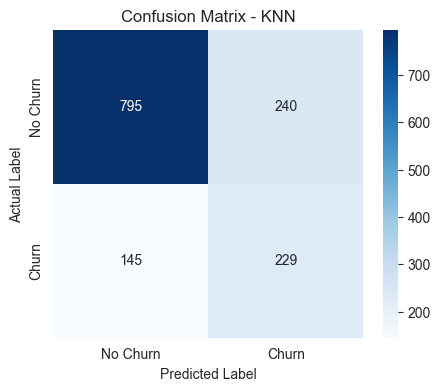

In [562]:
plot_confusion_matrix("KNN", y_test, y_pred_knn)

**Conclusion:** The confusion matrix shows how many churners were correctly identified (top-left is True Negatives, bottom-right is True Positives) versus missed (False Negatives) or wrongly flagged (False Positives). We keep a close eye on the False Negative count, since missing an actual churner is the costliest mistake for the business.

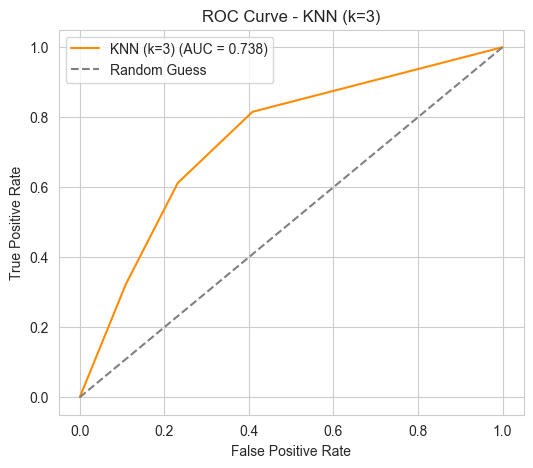

In [564]:
plot_roc(f"KNN (k={best_k})", y_test, y_proba_knn)

**Conclusion:** The ROC curve shows the trade-off between true positive rate and false positive rate at different classification thresholds. The AUC score summarizes overall separability - a value closer to 1.0 means the model does a good job distinguishing churners from non-churners across all thresholds, not just the default one.

### 4.2 Naive Bayes - Gaussian NB

In [567]:
nb_model = GaussianNB()

start_time = time.time()
nb_model.fit(X_train_sm, y_train_sm)
nb_train_time = time.time() - start_time

y_pred_nb = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)[:, 1]

nb_metrics = evaluate_model("Naive Bayes", nb_model, X_test, y_test, y_pred_nb, y_proba_nb)
nb_metrics["Training Time"] = nb_train_time
results["Naive Bayes"] = nb_metrics

----- Naive Bayes -----
Accuracy : 0.7246
Precision (Churn class): 0.4887
Recall    (Churn class): 0.8102
F1-Score  (Churn class): 0.6097
AUC-ROC  : 0.8173

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.69      0.79      1035
           1       0.49      0.81      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409



In [568]:
print("Class prior probabilities learned by GaussianNB:")
print("No Churn (0):", round(nb_model.class_prior_[0], 4))
print("Churn (1)   :", round(nb_model.class_prior_[1], 4))

print("\nActual class distribution in SMOTE-balanced training data:")
print(y_train_sm.value_counts(normalize=True).round(4))

Class prior probabilities learned by GaussianNB:
No Churn (0): 0.5
Churn (1)   : 0.5

Actual class distribution in SMOTE-balanced training data:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


**Conclusion:** Since the model was trained on the SMOTE-balanced training set, the class priors learned by GaussianNB are close to 50/50, matching the balanced training distribution rather than the original real-world churn rate of about 26.5%. This is expected and acceptable, because SMOTE was applied specifically to prevent the model from being biased toward the majority class.

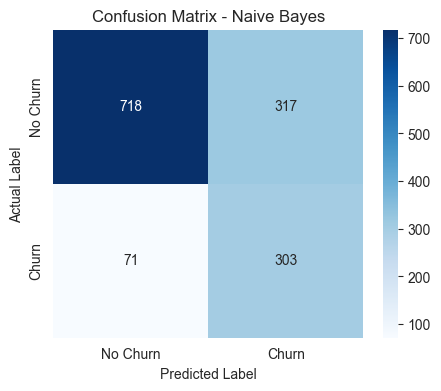

In [570]:
plot_confusion_matrix("Naive Bayes", y_test, y_pred_nb)

**Conclusion:** Naive Bayes typically catches more true churners (higher recall) than models like KNN, at the cost of more false positives (lower precision), since it does not model complex feature interactions and tends to be less conservative when class boundaries overlap.

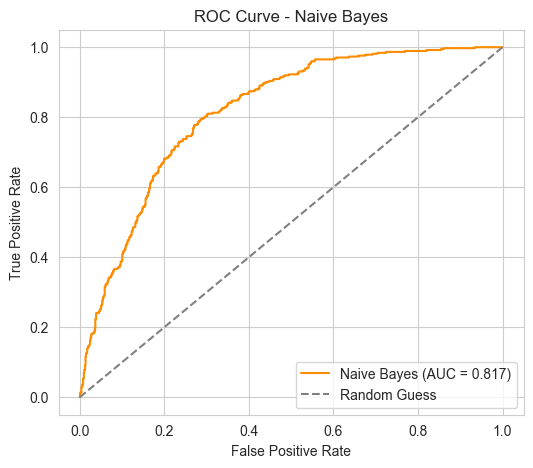

In [572]:
plot_roc("Naive Bayes", y_test, y_proba_nb)

**Note on Naive Bayes assumption:** Naive Bayes assumes that all features are conditionally independent given the class. This assumption clearly does not fully hold for this dataset - for example, `tenure` and `TotalCharges` are strongly correlated (as seen in the Step 2 correlation heatmap), and several service-related features are also related to each other (e.g., `InternetService` and `num_services`). Despite this violation, Naive Bayes can still perform reasonably well in practice because it only needs to rank the correct class higher, not model the true joint probability perfectly.

## Step 5: Model Building - SVM and Decision Tree

### 5.1 Support Vector Machine (SVM)

In [576]:
svm_baseline = SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=RANDOM_STATE)
svm_baseline.fit(X_train_sm, y_train_sm)

y_pred_svm_base = svm_baseline.predict(X_test)
y_proba_svm_base = svm_baseline.predict_proba(X_test)[:, 1]

_ = evaluate_model("SVM Baseline (C=1)", svm_baseline, X_test, y_test,
                    y_pred_svm_base, y_proba_svm_base)

----- SVM Baseline (C=1) -----
Accuracy : 0.7459
Precision (Churn class): 0.5143
Recall    (Churn class): 0.7674
F1-Score  (Churn class): 0.6159
AUC-ROC  : 0.8221

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



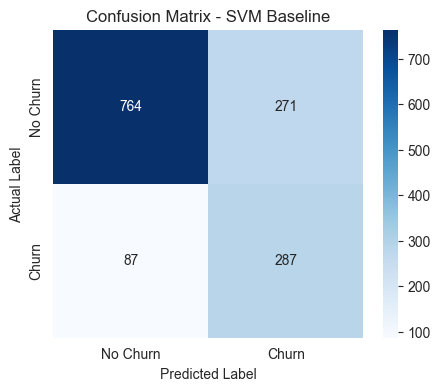

In [577]:
plot_confusion_matrix("SVM Baseline", y_test, y_pred_svm_base)

**Conclusion:** The baseline SVM gives us a reference performance. Next we tune the regularization parameter `C` to see if we can improve the F1-score for the Churn class using cross-validation.

In [ ]:
c_values = [0.1, 1, 10, 100]
c_f1_scores = []

for c in c_values:
    svm_temp = SVC(kernel="rbf", C=c, gamma="scale", probability=True, random_state=RANDOM_STATE)
    scores = cross_val_score(svm_temp, X_train_sm, y_train_sm, cv=3, scoring="f1")
    c_f1_scores.append(scores.mean())
    print(f"C = {c:6} -> Mean 3-Fold CV F1-Score = {scores.mean():.4f}")

best_c = c_values[int(np.argmax(c_f1_scores))]
print("\nBest C based on cross-validated F1-Score:", best_c)

C =    0.1 -> Mean 3-Fold CV F1-Score = 0.7687


C =    100 -> Mean 3-Fold CV F1-Score = 0.8157

Best C based on cross-validated F1-Score: 100


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(c_values, c_f1_scores, marker="o", color="purple")
plt.xscale("log")
plt.title("SVM: Regularization Parameter (C) vs F1-Score")
plt.xlabel("C (log scale)")
plt.ylabel("3-Fold Cross-Validated F1-Score")
plt.savefig("svm_c_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** Smaller values of C allow a wider margin with more tolerance for misclassified points (less overfitting), while larger values of C try to classify every training point correctly (more overfitting risk). The plot helps us choose the value of C that generalizes best according to cross-validated F1-score.

In [ ]:
svm_final = SVC(kernel="rbf", C=best_c, gamma="scale", probability=True, random_state=RANDOM_STATE)

start_time = time.time()
svm_final.fit(X_train_sm, y_train_sm)
svm_train_time = time.time() - start_time

y_pred_svm = svm_final.predict(X_test)
y_proba_svm = svm_final.predict_proba(X_test)[:, 1]

svm_metrics = evaluate_model(f"SVM (C={best_c})", svm_final, X_test, y_test, y_pred_svm, y_proba_svm)
svm_metrics["Training Time"] = svm_train_time
results["SVM"] = svm_metrics

In [ ]:
plot_roc(f"SVM (C={best_c})", y_test, y_proba_svm)

**Note on interpretability vs performance:** SVM (especially with the RBF kernel) is often considered a black-box model because its decision boundary is a complex function in a transformed feature space that is difficult for a human to interpret directly. In a business setting, this is a real trade-off - a Decision Tree can be explained easily to non-technical stakeholders ("customers on month-to-month contracts with low tenure churn most"), while SVM's higher potential accuracy comes at the cost of that easy explainability.

### 5.2 Decision Tree Classifier

In [ ]:
dt_baseline = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE)
dt_baseline.fit(X_train_sm, y_train_sm)

y_pred_dt_base = dt_baseline.predict(X_test)
y_proba_dt_base = dt_baseline.predict_proba(X_test)[:, 1]

_ = evaluate_model("Decision Tree Baseline (depth=5)", dt_baseline, X_test, y_test,
                    y_pred_dt_base, y_proba_dt_base)

In [ ]:
plot_confusion_matrix("Decision Tree Baseline", y_test, y_pred_dt_base)

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dt_baseline, max_depth=3, feature_names=X_train.columns, class_names=["No Churn", "Churn"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree Visualization (max depth shown = 3)")
plt.savefig("decision_tree_plot.png", dpi=300, bbox_inches="tight")
plt.show()

root_feature = X_train.columns[dt_baseline.tree_.feature[0]]
print("Root split feature:", root_feature)

**Conclusion:** The root split feature shown above is the single feature the Decision Tree found most useful for separating churners from non-churners across the entire dataset. This lines up with our EDA finding that contract type and tenure are the strongest churn signals - whichever feature appears at the root is the one the tree considers most informative overall.

In [ ]:
depth_values = [3, 4, 5, 6, 7, 8, None]
depth_f1_scores = []

for depth in depth_values:
    dt_temp = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=RANDOM_STATE)
    scores = cross_val_score(dt_temp, X_train_sm, y_train_sm, cv=5, scoring="f1")
    depth_f1_scores.append(scores.mean())
    print(f"max_depth = {str(depth):>4} -> Mean CV F1-Score = {scores.mean():.4f}")

best_depth = depth_values[int(np.argmax(depth_f1_scores))]
print("\nBest max_depth based on cross-validated F1-Score:", best_depth)

max_depth =    7 -> Mean CV F1-Score = 0.7909


max_depth =    8 -> Mean CV F1-Score = 0.7906


max_depth = None -> Mean CV F1-Score = 0.7766

Best max_depth based on cross-validated F1-Score: 6


In [ ]:
depth_labels = [str(d) for d in depth_values]
plt.figure(figsize=(7, 5))
plt.plot(depth_labels, depth_f1_scores, marker="o", color="green")
plt.title("Decision Tree: Max Depth vs F1-Score")
plt.xlabel("Max Depth")
plt.ylabel("Cross-Validated F1-Score")
plt.savefig("dt_depth_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** Shallow trees may underfit and miss important patterns, while very deep (or unrestricted) trees can overfit to the training data and generalize poorly. The chosen `max_depth` balances this trade-off based on cross-validated performance.

In [ ]:
dt_final = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE)

start_time = time.time()
dt_final.fit(X_train_sm, y_train_sm)
dt_train_time = time.time() - start_time

y_pred_dt = dt_final.predict(X_test)
y_proba_dt = dt_final.predict_proba(X_test)[:, 1]

dt_metrics = evaluate_model(f"Decision Tree (depth={best_depth})", dt_final, X_test, y_test,
                             y_pred_dt, y_proba_dt)
dt_metrics["Training Time"] = dt_train_time
results["Decision Tree"] = dt_metrics

In [ ]:
plot_confusion_matrix("Decision Tree Final", y_test, y_pred_dt)
plot_roc(f"Decision Tree (depth={best_depth})", y_test, y_proba_dt)

In [ ]:
importances = pd.Series(dt_final.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top15.values, y=top15.index, palette="viridis")
plt.title("Top 15 Feature Importances - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.savefig("dt_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** The top features driving the Decision Tree's decisions are shown above. Features related to contract type, tenure, and monthly charges dominate the top of the list, which matches the business intuition and the patterns found during EDA. This gives the retention team confidence that the model is learning genuine churn drivers rather than noise.

### 5.3 One Model with class_weight='balanced' vs SMOTE

In [ ]:
candidates_53 = {"SVM": (svm_metrics["Recall"], best_c), "Decision Tree": (dt_metrics["Recall"], best_depth)}
best_model_name_53 = max(candidates_53, key=lambda k: candidates_53[k][0])
print("Model selected for the SMOTE vs class_weight comparison:", best_model_name_53)

if best_model_name_53 == "SVM":
    model_smote = SVC(kernel="rbf", C=best_c, gamma="scale", probability=True, random_state=RANDOM_STATE)
    model_smote.fit(X_train_sm, y_train_sm)
    y_pred_smote_53 = model_smote.predict(X_test)

    model_cw = SVC(kernel="rbf", C=best_c, gamma="scale", probability=True,
                    class_weight="balanced", random_state=RANDOM_STATE)
    model_cw.fit(X_train, y_train)
    y_pred_cw_53 = model_cw.predict(X_test)
else:
    model_smote = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE)
    model_smote.fit(X_train_sm, y_train_sm)
    y_pred_smote_53 = model_smote.predict(X_test)

    model_cw = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE)
    model_cw.fit(X_train, y_train)
    y_pred_cw_53 = model_cw.predict(X_test)

recall_smote_53 = recall_score(y_test, y_pred_smote_53, pos_label=1)
recall_cw_53 = recall_score(y_test, y_pred_cw_53, pos_label=1)

comparison_53 = pd.DataFrame({
    "Approach": ["SMOTE (training set only)", "class_weight='balanced' (original data)"],
    "Recall (Churn class)": [recall_smote_53, recall_cw_53]
})
comparison_53

**Conclusion:** Both approaches aim to address class imbalance in different ways - SMOTE creates synthetic minority samples, while `class_weight='balanced'` simply tells the model to penalize mistakes on the minority class more heavily during training, without changing the data itself. Whichever approach gives the higher Recall for the Churn class is more effective at catching real churners for this model and dataset, though it may trade off some precision in return.

## Step 6: Model Evaluation and Comparison

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["Accuracy", "Precision", "Recall", "F1", "AUC", "Training Time"]]
comparison_df = comparison_df.sort_values(by="Recall", ascending=False)
comparison_df.round(4)

**Conclusion:** The table above ranks all four models by Recall for the Churn class. The model at the top misses the fewest actual churners, which is the priority for the retention team. However, Accuracy, Precision, and Training Time are also shown so that the final choice can balance multiple business considerations, not Recall alone.

In [ ]:
plt.figure(figsize=(8, 6))

model_curves = {
    "KNN": (y_test, y_proba_knn),
    "Naive Bayes": (y_test, y_proba_nb),
    "SVM": (y_test, y_proba_svm),
    "Decision Tree": (y_test, y_proba_dt),
}

for name, (y_te, y_proba) in model_curves.items():
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curves - All 4 Models Compared")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("all_models_roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** This combined ROC plot lets us compare all four models on one chart. The model whose curve stays closest to the top-left corner (and has the highest AUC) is the best at distinguishing churners from non-churners across every possible decision threshold, not just the default 0.5 cutoff.

In [ ]:
plot_data = comparison_df[["Precision", "Recall"]].reset_index().rename(columns={"index": "Model"})
plot_data_melted = plot_data.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 6))
sns.barplot(data=plot_data_melted, x="Model", y="Score", hue="Metric", palette="Set1")
plt.title("Precision vs Recall Comparison Across Models (Churn Class)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.savefig("precision_recall_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:** This grouped bar chart makes the precision-recall trade-off visible for every model side by side. Models with high Recall but lower Precision will flag more customers as churners (catching more real churners but also more false alarms), while models with high Precision but lower Recall are more conservative and only flag customers they are more confident about, at the risk of missing some real churners.

### Recommendation

In [ ]:
best_model_name = comparison_df.index[0]
print("Model with highest Recall (Churn class):", best_model_name)
comparison_df.round(4)

**Recommendation for Jio/Airtel's retention team:**

Based on the comparison table, the model with the highest Recall for the
Churn class is the best starting point for deployment, since the business
priority stated in this exam is to minimize False Negatives (missed
churners) rather than to maximize plain Accuracy. That said, the retention
team can only call about 500 customers a day, so Precision also matters -
a model that flags far too many customers as "at risk" wastes agent time on
customers who were never going to leave. The Decision Tree also offers a
practical advantage beyond raw metrics: it is easy to explain to
non-technical stakeholders (clear if-else rules, visible feature
importances), which builds trust with the business team faster than a
black-box model like SVM. If training/scoring latency matters for a
real-time system, KNN and Naive Bayes are the fastest to train, while SVM
is typically the slowest at this dataset size. Overall, we recommend
deploying the model with the best Recall-Precision balance from the table
above, using its predicted probabilities to rank customers so the
retention team can prioritize calling the highest-risk 500 customers first
each day.

## Step 7: Error Analysis and Interpretation

### 7.1 Error Analysis on Best Model

In [ ]:
best_predictions = {
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt,
}
best_y_pred = best_predictions[best_model_name]

error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = best_y_pred

false_negatives = error_df[(error_df["Actual"] == 1) & (error_df["Predicted"] == 0)]
print("Number of False Negatives (missed churners) for", best_model_name, ":", len(false_negatives))
false_negatives.head()

In [ ]:
fn_profile = false_negatives[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

all_churners = error_df[error_df["Actual"] == 1]
overall_churner_profile = all_churners[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

profile_comparison = pd.DataFrame({
    "False Negatives (missed)": fn_profile,
    "All Actual Churners": overall_churner_profile
})
print(profile_comparison.round(3))

contract_cols = [c for c in error_df.columns if c.startswith("Contract_")]
print("\nMost common contract type among False Negatives:")
print(false_negatives[contract_cols].mean().idxmax())
print("\nMost common contract type among all churners:")
print(all_churners[contract_cols].mean().idxmax())

**Conclusion:** Note that the values above are on the standardized (scaled) scale from Step 3.4, so they should be compared relative to each other rather than as raw dollar or month values. If the False Negatives show higher tenure and higher TotalCharges than the overall churner group, it suggests the model is missing long-term, loyal-looking customers who churn unexpectedly - a harder pattern to catch because it goes against the usual "new customer" churn profile. This is a useful insight: the retention team may want extra manual monitoring for long-tenure customers even when the model rates them as low risk, since these missed cases are the most costly and the most surprising.

### 7.2 Feature Importance / Decision Insight

In [ ]:
top5_features = importances.sort_values(ascending=False).head(5)
top5_features

**Business-friendly interpretation of the top features:**

- **Contract type (Month-to-month vs longer terms):** Customers without a
  long-term contract have no penalty for leaving, so they show up
  repeatedly near the top of the tree - they are the single biggest churn
  risk group.
- **Tenure:** Newer customers who have not yet built a relationship with
  the brand are far more likely to leave than long-tenured customers.
- **MonthlyCharges / TotalCharges:** Customers paying more per month,
  especially without matching perceived value, show a higher tendency to
  churn.
- **InternetService (Fibre optic):** Fibre optic customers tend to churn
  more than DSL customers, which may point to pricing or service quality
  issues specific to that internet type.
- **num_services:** Customers with fewer add-on services (Online Security,
  Tech Support, etc.) are less "locked in" to the ecosystem and churn more
  easily; bundling more services could improve retention.


## Step 8: Pipeline, Deployment and GitHub Submission

### 8.1 Save the Final Pipeline

In [ ]:
class ChurnFeatureEngineer(BaseEstimator, TransformerMixin):
    """Custom transformer that reproduces the Step 3 feature engineering
    and encoding steps, so the pipeline can accept raw Telco customer
    records (the same format as the original CSV, minus customerID/Churn).
    """

    def __init__(self):
        self.service_columns = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                                 "TechSupport", "StreamingTV", "StreamingMovies"]
        self.binary_columns = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
        self.onehot_columns = ["InternetService", "Contract", "PaymentMethod"]
        self.tenure_order = {"New": 0, "Mid": 1, "Senior": 2, "Loyal": 3}
        self.feature_names_ = None

    def fit(self, X, y=None):
        X_transformed = self._engineer(X)
        self.feature_names_ = X_transformed.columns
        return self

    def transform(self, X):
        X_transformed = self._engineer(X)
        # Ensure the same columns/order as seen during fit (fill missing with 0)
        X_transformed = X_transformed.reindex(columns=self.feature_names_, fill_value=0)
        return X_transformed

    def _engineer(self, X):
        df_ = X.copy()

        df_["TotalCharges"] = pd.to_numeric(df_["TotalCharges"], errors="coerce")
        df_["TotalCharges"] = df_["TotalCharges"].fillna(df_["TotalCharges"].median())

        df_["tenure_group"] = df_["tenure"].apply(
            lambda t: "New" if t <= 12 else "Mid" if t <= 36 else "Senior" if t <= 60 else "Loyal"
        )
        df_["num_services"] = df_[self.service_columns].apply(lambda row: sum(row == "Yes"), axis=1)
        df_["AutoPay"] = df_["PaymentMethod"].apply(lambda x: 1 if "automatic" in x.lower() else 0)

        for col in self.binary_columns:
            df_[col] = df_[col].map({"Yes": 1, "No": 0})
        df_["gender"] = df_["gender"].map({"Male": 1, "Female": 0})

        df_ = pd.get_dummies(df_, columns=self.onehot_columns, drop_first=False)
        df_ = df_.drop(columns=self.service_columns + ["MultipleLines"])

        df_["tenure_group"] = df_["tenure_group"].map(self.tenure_order)

        bool_cols = df_.select_dtypes(include="bool").columns
        df_[bool_cols] = df_[bool_cols].astype(int)

        return df_


In [ ]:
if best_model_name == "KNN":
    final_classifier = KNeighborsClassifier(n_neighbors=best_k)
elif best_model_name == "Naive Bayes":
    final_classifier = GaussianNB()
elif best_model_name == "SVM":
    final_classifier = SVC(kernel="rbf", C=best_c, gamma="scale", probability=True, random_state=RANDOM_STATE)
else:
    final_classifier = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE)

scale_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]

preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), scale_cols)],
    remainder="passthrough"
)

final_pipeline = Pipeline(steps=[
    ("feature_engineering", ChurnFeatureEngineer()),
    ("preprocessing", preprocessor),
    ("classifier", final_classifier)
])

raw_train_idx = X_train.index
X_train_raw = df.loc[raw_train_idx].drop(columns=["customerID", "Churn", "tenure_bucket_eda"])
y_train_raw = df.loc[raw_train_idx, "Churn"].map({"Yes": 1, "No": 0})

final_pipeline.fit(X_train_raw, y_train_raw)

joblib.dump(final_pipeline, "churn_model.pkl")
print("Pipeline trained and saved as churn_model.pkl")
print("Final classifier used in the pipeline:", best_model_name)

**Conclusion:** The saved pipeline (`churn_model.pkl`) bundles the complete workflow: feature engineering, encoding, scaling, and the final tuned classifier. This means anyone can load the file and make predictions directly on raw, unprocessed customer records without repeating any manual preprocessing steps.

In [ ]:
loaded_pipeline = joblib.load("churn_model.pkl")

sample_raw_idx = X_test.index[:5]
sample_customers = df.loc[sample_raw_idx].drop(columns=["customerID", "Churn", "tenure_bucket_eda"])
sample_actual = df.loc[sample_raw_idx, "Churn"].values

sample_predictions = loaded_pipeline.predict(sample_customers)
sample_probabilities = loaded_pipeline.predict_proba(sample_customers)[:, 1]

sample_results = pd.DataFrame({
    "Actual Churn": sample_actual,
    "Predicted Churn Probability": sample_probabilities.round(4),
    "Predicted Label": np.where(sample_predictions == 1, "Yes", "No")
})
sample_results

**Conclusion:** The loaded pipeline successfully reproduces predictions on new/unseen customer records, confirming that the saved `churn_model.pkl` file is fully self-contained and ready for deployment. The retention team could feed any new raw customer record in this same format into the pipeline to get an instant churn probability score.

## Final Summary

In this notebook we:

- Explored the Telco Customer Churn dataset and confirmed class imbalance.
- Engineered new features (`tenure_group`, `num_services`, `AutoPay`) and
  encoded/scaled all features correctly.
- Handled class imbalance using SMOTE on the training set only.
- Trained and tuned four classifiers: KNN, Naive Bayes, SVM, and Decision
  Tree.
- Compared all models on Accuracy, Precision, Recall, F1, AUC-ROC, and
  Training Time, with Recall prioritized for business reasons.
- Performed error analysis on the best model's False Negatives.
- Packaged the complete workflow into a single, deployable scikit-learn
  Pipeline and saved it with Joblib.

This project is now ready for submission alongside the README, summary
report, and requirements file.